In [1]:
import numpy as np 
import pandas as pd 
import os
import shutil
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from diffusers import StableDiffusionPipeline
import torch
df = pd.read_csv('/kaggle/input/hgvoid/hvoid.csv')
pipe = StableDiffusionPipeline.from_pretrained("gowri-39/different-types-of-agriculture").to("cuda")


2025-10-08 11:46:08.595971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759923968.618121     235 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759923968.624950     235 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--gowri-39--different-types-of-agriculture/snapshots/855af582379909f626b3f6c85028f1194cb2990c/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--gowri-39--different-types-of-agriculture/snapshots/855af582379909f626b3f6c85028f1194cb2990c/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--gowri-39--different-types-of-agriculture/snapshots/855af582379909f626b3f6c85028f1194cb2990c/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--gowri-39--different-types-of-agriculture/snapshots/855af582379909f626b3f6c85028f1194cb2990c/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [2]:
image_paths = df.image_path.to_list()

target_root = "/kaggle/working/targeted_Dset"

for path in image_paths:
    class_name = os.path.basename(os.path.dirname(path))
    file_name = os.path.basename(path)
    
    target_dir = os.path.join(target_root, class_name)
    os.makedirs(target_dir, exist_ok=True)
    
    shutil.copy2(path, os.path.join(target_dir, file_name))

print('done')


done


In [3]:
init_image = Image.open("/kaggle/working/targeted_Dset/Tomato___Early_blight/00c5c908-fc25-4710-a109-db143da23112___RS_Erly.B 7778_aug_004.jpg").convert("RGB")
init_image = init_image.resize((512, 512))

prompt = "Tomato leaf showing early blight symptoms"
result = pipe(prompt=prompt, image=init_image, strength=0.6, guidance_scale=7.5).images[0]
result.save("generated_early_blight.jpg")

  0%|          | 0/50 [00:00<?, ?it/s]

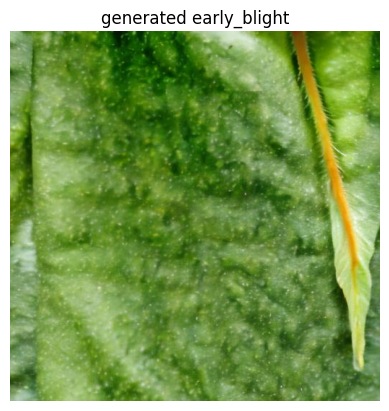

In [4]:
img_path = '/kaggle/working/generated_early_blight.jpg'
img = Image.open(img_path)
plt.imshow(img)
plt.title('generated early_blight')
plt.axis('off')
plt.show()

In [5]:
folder_path = "/kaggle/working/targeted_Dset/Tomato___Early_blight"
prompt = "Tomato leaf showing early blight symptoms"

image_list = []
for fname in os.listdir(folder_path)[:10]:
    img_path = os.path.join(folder_path, fname)
    img = Image.open(img_path).convert("RGB").resize((512, 512))
    image_list.append(np.array(img))

avg_array = np.mean(image_list, axis=0).astype(np.uint8)
avg_image = Image.fromarray(avg_array)

result = pipe(prompt=prompt, image=avg_image, strength=0.6, guidance_scale=7.5).images[0]

result.save("generated_early_blight_from_10.jpg")
result.show()


  0%|          | 0/50 [00:00<?, ?it/s]

Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpdebvhu67.PNG'


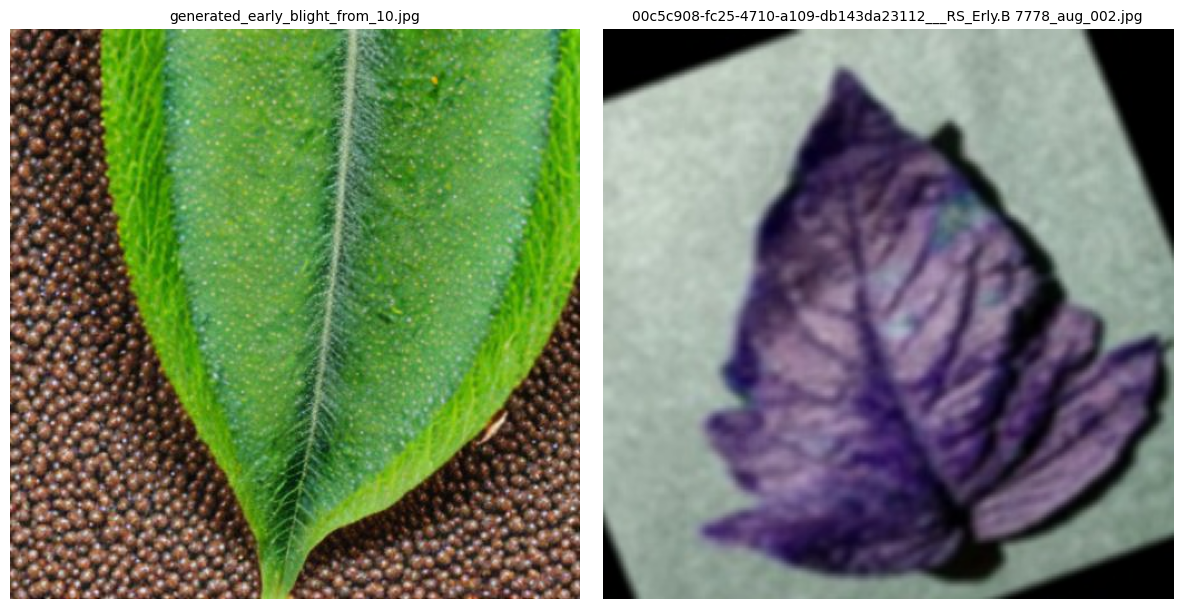

In [6]:
img_paths = [
    '/kaggle/working/generated_early_blight_from_10.jpg',
    '/kaggle/working/targeted_Dset/Tomato___Early_blight/00c5c908-fc25-4710-a109-db143da23112___RS_Erly.B 7778_aug_002.jpg'  # İkinci görsel farklıysa yolunu değiştir
]

images = [Image.open(p) for p in img_paths]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, img, path in zip(axes, images, img_paths):
    ax.imshow(img)
    ax.set_title(path.split('/')[-1], fontsize=10) 
    ax.axis('off')

plt.tight_layout()
plt.show()


# When the Motif Speaks Louder Than the Prompt
These visuals are so niche and semantically sharp that Stable Diffusion struggles to assign meaningful context to the prompt or truly grasp the essence of the image—so at this point, it makes more sense to intentionally strip the prompt of meaning and let the image itself lead the generation, because here, it's not the text that should speak, but the motif.

In [7]:
folder_path = "/kaggle/working/targeted_Dset/Tomato___Early_blight"
prompt = ""

image_list = []
for fname in os.listdir(folder_path)[:20]:
    img_path = os.path.join(folder_path, fname)
    img = Image.open(img_path).convert("RGB").resize((512, 512))
    image_list.append(np.array(img))

avg_array = np.mean(image_list, axis=0).astype(np.uint8)
avg_image = Image.fromarray(avg_array)

result = pipe(prompt=prompt, image=avg_image, strength=0.6, guidance_scale=7.5).images[0]

result.save("generated_early_blight_from_10_wout_prompt.jpg")
result.show()


  0%|          | 0/50 [00:00<?, ?it/s]

Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmp57stbmcp.PNG'


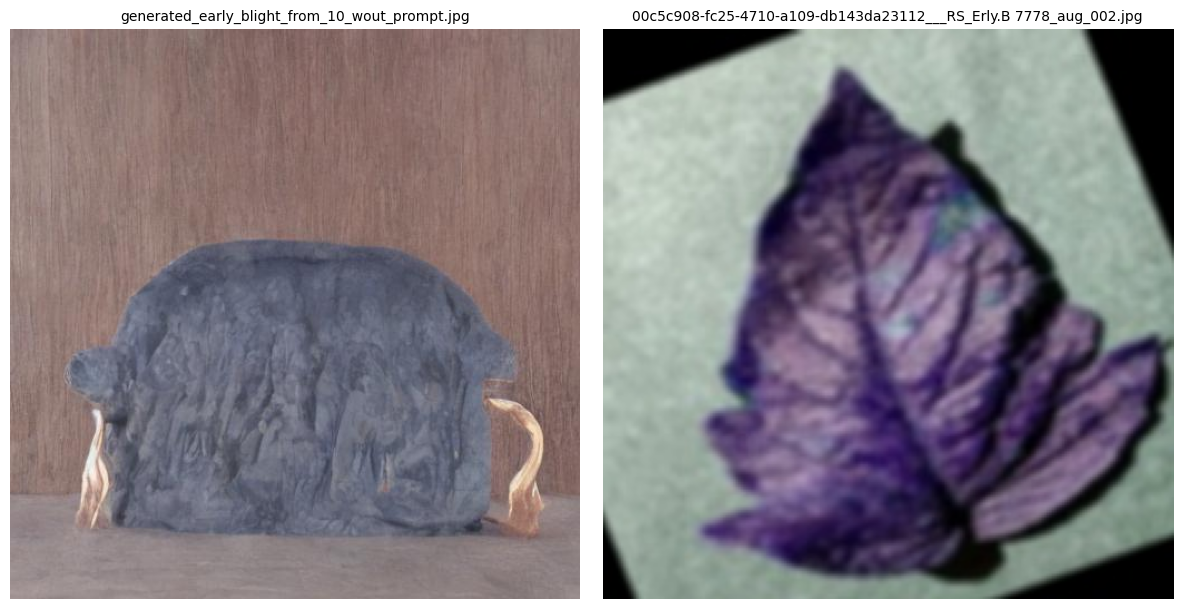

In [8]:
img_paths = [
    '/kaggle/working/generated_early_blight_from_10_wout_prompt.jpg',
    '/kaggle/working/targeted_Dset/Tomato___Early_blight/00c5c908-fc25-4710-a109-db143da23112___RS_Erly.B 7778_aug_002.jpg'  
]

images = [Image.open(p) for p in img_paths]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, img, path in zip(axes, images, img_paths):
    ax.imshow(img)
    ax.set_title(path.split('/')[-1], fontsize=10) 
    ax.axis('off')

plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

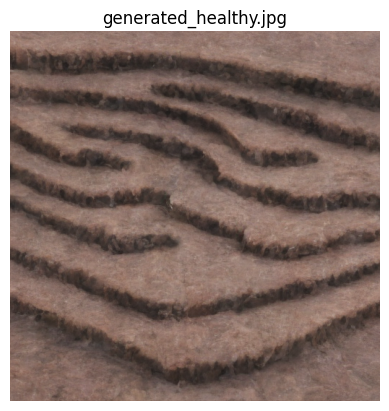

In [9]:
folder_path = "/kaggle/working/targeted_Dset/Tomato___healthy"
prompt = ""
negative_prompt = ""


image_list = []
for fname in os.listdir(folder_path)[:3]:
    img_path = os.path.join(folder_path, fname)
    img = Image.open(img_path).convert("RGB").resize((512, 512))
    image_list.append(np.array(img))

avg_array = np.mean(image_list, axis=0).astype(np.uint8)
avg_image = Image.fromarray(avg_array)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=avg_image,
    strength=0.3,
    guidance_scale=7.5
).images[0]


result.save("generated_healthy.jpg")
plt.imshow(result)
plt.axis('off')  
plt.title("generated_healthy.jpg")
plt.show()


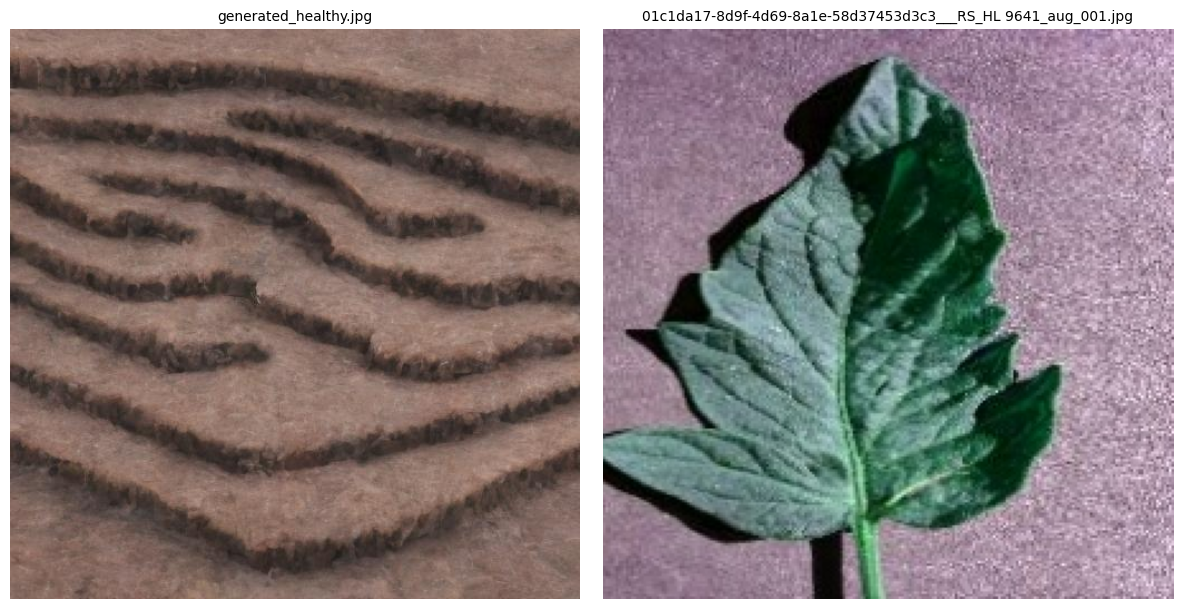

In [10]:
img_paths = [
    '/kaggle/working/generated_healthy.jpg',
    '/kaggle/working/targeted_Dset/Tomato___healthy/01c1da17-8d9f-4d69-8a1e-58d37453d3c3___RS_HL 9641_aug_001.jpg'  
]

images = [Image.open(p) for p in img_paths]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, img, path in zip(axes, images, img_paths):
    ax.imshow(img)
    ax.set_title(path.split('/')[-1], fontsize=10) 
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
folder_path = "/kaggle/working/targeted_Dset/Tomato___healthy"
for i, fname in enumerate(os.listdir(folder_path)[:5]):
    img_path = os.path.join(folder_path, fname)
    img = Image.open(img_path).convert("RGB").resize((512, 512))
    
    result = pipe(
        prompt="Generate only a single tomato leaf. It must closely resemble the input.",
        negative_prompt="house, building, cartoon, abstract, fantasy, architecture, animal, human, unrealistic texture",
        image=img,
        strength=0.2,
        guidance_scale=7.5
    ).images[0]
    
    result.save(f"generated_leaf_{i}.jpg")


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

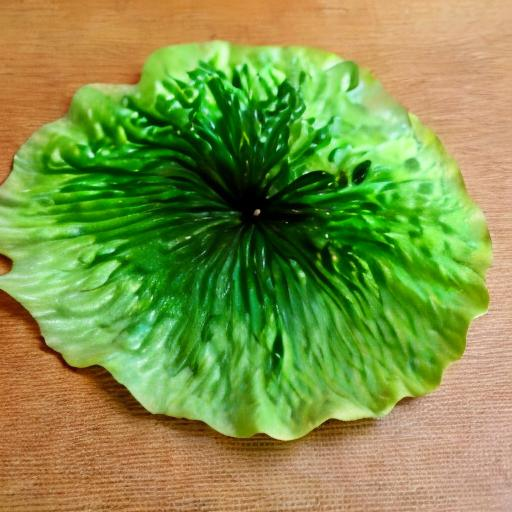

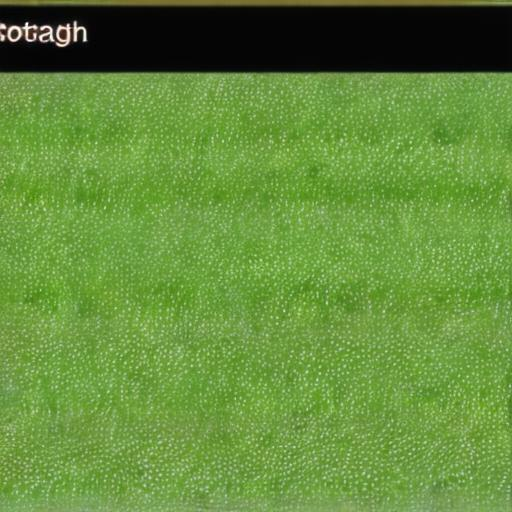

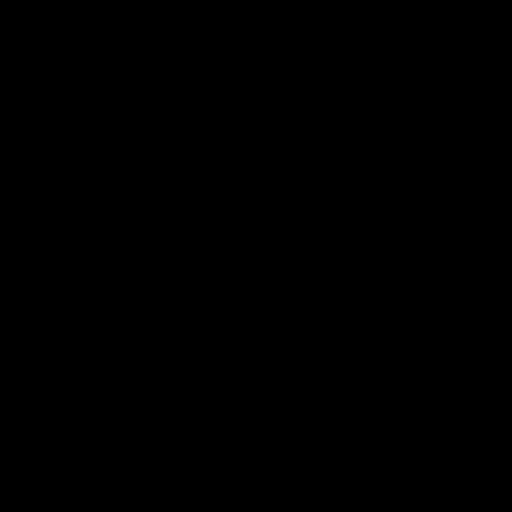

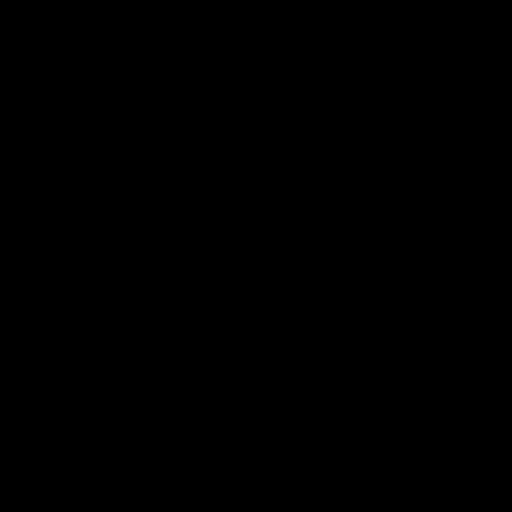

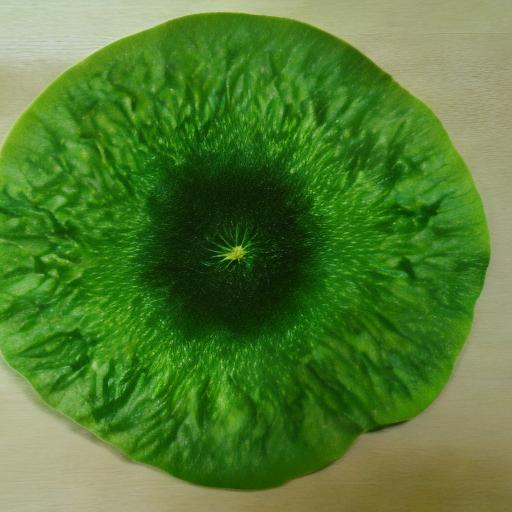

In [12]:
for i in range(5):
    img = Image.open(f"generated_leaf_{i}.jpg")
    display(img)


# Stuck on the Tail Distribution
I have 2,000 agricultural images, which, compared to the millions of images in Stable Diffusion’s general training dataset, form a "tail distribution" scenario. Even when given a simple prompt like "leaf," the model defaults to producing bright green, cliché images—which do not reflect the characteristics of my specific dataset. Even if I fine-tune the model, 2,000 images are too few relative to the model’s main training set to guarantee that it will break its general tendencies and stop generating meaningless or irrelevant images. To overcome this problem, I will adopt a different approach: instead of showing Stable Diffusion images one by one and asking it to "generate something similar," I will use 3D rendering tools like Blender, Unity, or OpenUSD to create synthetic data. Using these tools, I can perform data augmentation based on my existing 2,000 images and generate a sufficiently large and diverse dataset to overcome Stable Diffusion’s tail distribution issue. This strategy allows me to pursue two possible paths: either I can fine-tune Stable Diffusion more effectively with the augmented dataset, or I can train my own GAN model using this dataset. In either case, the outcome will be a system capable of generating problem-specific, meaningful, and coherent images.